# 📐 Numerical Integration over Polygons: A Visual Guide
### Comparing Gauss–Legendre Quadrature & 8-Node Spline Finite Elements

[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/Jordi-Ab/inter-university-algorithms/main?labpath=polygon-integration%2FNumerical_Integration_over_Polygons_Visual_Guide.ipynb)
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Jordi-Ab/inter-university-algorithms/blob/main/polygon-integration/Numerical_Integration_over_Polygons_Visual_Guide.ipynb)
[![Python 3.11](https://img.shields.io/badge/python-3.11-blue.svg)](https://www.python.org/downloads/release/python-3110/)

---

## 🎯 Welcome! What is this notebook about?

In basic calculus, calculating the area under a curve $\int_a^b f(x) dx$ or volume over a flat square $[a, b] \times [c, d]$ is straightforward. But in the real world—such as territorial analysis, fluid mechanics, civil engineering, and computational geometry—the "floor" of your domain is almost never a neat square: **it is an irregular polygon** (triangles, quadrilaterals, pentagons, or property plots).

This notebook provides an **intuitive, visual-first interactive walkthrough** for calculating numerical integrals over polygons using two powerful approaches:
1. **Gauss–Legendre Quadrature** (*"Magic Sampling Points on Triangles & Boundaries"*).
2. **8-Node Quadrilateral Spline Finite Elements** (*"The Method from Li, Lamberti & Dagnino (2009)"*).

> 💡 **Where does the class spreadsheet come from?**  
> If you have seen the course spreadsheet with formulas for $a, b, c, d$, $S_1, S_2, S_3, S_4$, and $C_{V_i}, C_{E_j}$, that spreadsheet is an implementation of **Method 2 (the 8-node quadrilateral spline finite element)**! In Section 4, we explain step-by-step how every cell in that spreadsheet works geometrically.


In [11]:
# ==============================================================================
# Setup & Styling
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from mpl_toolkits.mplot3d import Axes3D
from scipy import integrate
import pandas as pd

# Optional interactive widgets (gracefully falls back if running in non-widget environment)
try:
    import ipywidgets as widgets
    from IPython.display import display
    HAS_WIDGETS = True
except ImportError:
    HAS_WIDGETS = False

# Professional plot aesthetics
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#CCCCCC'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['grid.color'] = '#EBEBEB'
plt.rcParams['grid.linestyle'] = '--'

print("[OK] Libraries loaded successfully! Ready to explore geometry.")

[OK] Libraries loaded successfully! Ready to explore geometry.


---
## 🏔️ Section 1: The Problem – Finding Volume over a "Weird Floor"

Imagine you are building a circus tent over an irregular 6-sided property plot in the plane.  
The boundary of your floor has 6 corners:
* $A = (0.0, 0.25)$
* $B = (0.1, 0.0)$
* $C = (0.7, 0.2)$
* $D = (1.0, 0.5)$
* $E = (0.75, 0.85)$
* $F = (0.5, 1.0)$

Above this floor, we want to find the **total volume under two test surfaces** (from the lecture presentation):
1. **$f_1(x, y) = \exp\left(-100\left((x - 0.5)^2 + (y - 0.5)^2\right)\right)$**:  
   *Visual intuition:* A sharp, steep volcanic mountain peak centered right at $(0.5, 0.5)$. It drops off very quickly towards zero.
2. **$f_2(x, y) = \sqrt{(x - 0.5)^2 + (y - 0.5)^2}$**:  
   *Visual intuition:* A smooth conical crater or funnel centered at $(0.5, 0.5)$.

Let's visualize the floor and the 3D surface!


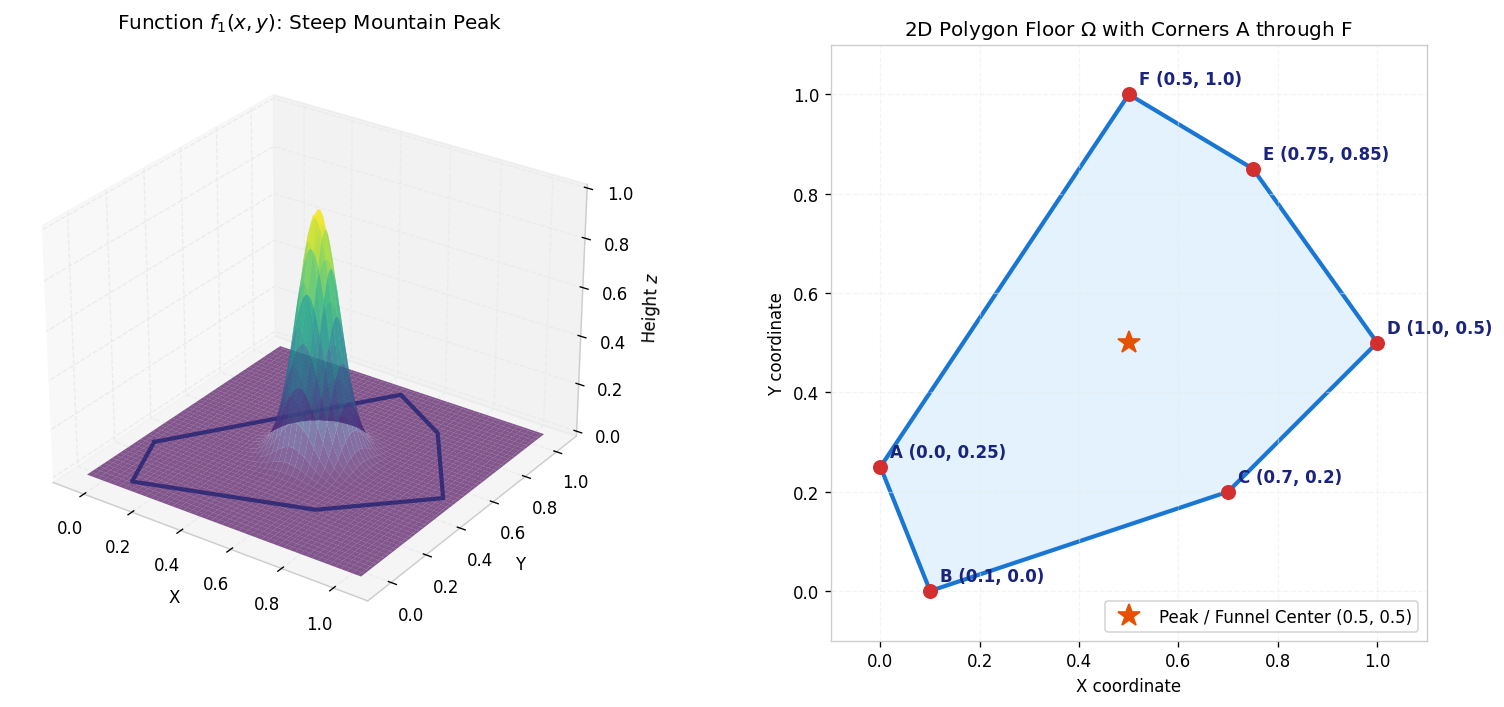

In [12]:
# 1. Define the polygon vertices (from the lecture example)
polygon_vertices = np.array([
    [0.0, 0.25],  # A
    [0.1, 0.0],   # B
    [0.7, 0.2],   # C
    [1.0, 0.5],   # D
    [0.75, 0.85], # E
    [0.5, 1.0]    # F
])
vertex_names = ['A', 'B', 'C', 'D', 'E', 'F']

# 2. Define the two benchmark test functions
def f1(x, y):
    """Steep Gaussian peak centered at (0.5, 0.5)"""
    return np.exp(-100.0 * ((x - 0.5)**2 + (y - 0.5)**2))

def f2(x, y):
    """Conical surface / distance cone centered at (0.5, 0.5)"""
    return np.sqrt((x - 0.5)**2 + (y - 0.5)**2)

# 3. Create a 3D visual representation
fig = plt.figure(figsize=(14, 6))

# Subplot 1: 3D View of f1 over the polygon
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
x_grid = np.linspace(-0.05, 1.05, 100)
y_grid = np.linspace(-0.05, 1.05, 100)
X, Y = np.meshgrid(x_grid, y_grid)
Z1 = f1(X, Y)

# Draw ground polygon floor
poly_closed = np.vstack([polygon_vertices, polygon_vertices[0]])
ax1.plot(poly_closed[:, 0], poly_closed[:, 1], np.zeros_like(poly_closed[:, 0]), 
         '#1F77B4', lw=2.5, label='Polygon Floor $\\Omega$')
ax1.plot_surface(X, Y, Z1, cmap='viridis', alpha=0.65, edgecolor='none')
ax1.set_title("Function $f_1(x, y)$: Steep Mountain Peak", fontsize=12, pad=10)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Height $z$')
ax1.view_init(elev=28, azim=-55)

# Subplot 2: 2D Footprint of the Polygon Domain
ax2 = fig.add_subplot(1, 2, 2)
patch = patches.Polygon(polygon_vertices, closed=True, facecolor='#E3F2FD', edgecolor='#1976D2', lw=2.5)
ax2.add_patch(patch)

# Plot vertices with clear labels
for (x, y), name in zip(polygon_vertices, vertex_names):
    ax2.plot(x, y, 'o', color='#D32F2F', markersize=8)
    ax2.text(x + 0.02, y + 0.02, f"{name} ({x}, {y})", fontsize=10, weight='bold', color='#1A237E')

# Mark the center (0.5, 0.5) where the mountain peak sits
ax2.plot(0.5, 0.5, '*', color='#E65100', markersize=14, label='Peak / Funnel Center (0.5, 0.5)')
ax2.set_xlim(-0.1, 1.1)
ax2.set_ylim(-0.1, 1.1)
ax2.set_aspect('equal')
ax2.set_title("2D Polygon Floor $\\Omega$ with Corners A through F", fontsize=12)
ax2.set_xlabel('X coordinate')
ax2.set_ylabel('Y coordinate')
ax2.legend(loc='lower right', frameon=True)
ax2.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()


---
## 💡 Section 2: The Core Intuition – How Do We Integrate Numerically?

If we were doing a naive simulation, we might divide the floor into 1,000,000 tiny pixels and add up all the little columns. But that is **extremely slow, inefficient, and creates jagged errors** along diagonal boundaries.

Instead, mathematicians use **Quadrature**:
> 🌟 **The Golden Rule of Quadrature:**  
> Find a small number of **smart sample points** $(x_i, y_i)$ and multiply each point by a **weight** $w_i$:
> $$\iint_{\Omega} f(x, y) \, dxdy \approx \sum_{i=1}^N w_i \cdot f(x_i, y_i)$$

If you place the sample points randomly, the result is poor. But if you place them at **mathematically optimal locations**, you can get exact answers with astonishingly few points!

Let's look at the two different ways to do this on our polygon:
1. **Method 1: Gauss–Legendre** cuts the polygon into triangles and places sample points inside each triangle.
2. **Method 2: 8-Node Spline** cuts the polygon into quadrilaterals and samples the 4 corners + 4 edge midpoints.


---
## 🍕 Section 3: Method 1 – Gauss–Legendre Quadrature on Triangles

Like slicing a pizza, any polygon can be easily sliced into triangles!  
For our 6-sided polygon, we can fan out 4 triangles from vertex $F(0.5, 1.0)$:
1. Triangle 1: $\triangle F A B$
2. Triangle 2: $\triangle F B C$
3. Triangle 3: $\triangle F C D$
4. Triangle 4: $\triangle F D E$

On each triangle, Gauss–Legendre theory gives us magical sampling rules:
* **1-Point Rule (Order 1)**: Sample at the triangle's **centroid** with weight = Triangle Area.
* **3-Point Rule (Order 2)**: Sample at the **3 edge midpoints** with weight = $\frac{1}{3} \times \text{Area}$. (Exact for all flat planes and parabolic surfaces!)
* **7-Point Dunavant Rule (Order 5)**: 1 center point + 2 rings of 3 symmetric points. (Exact for high-degree polynomials!)

Let's implement this and visually plot the sampling nodes!


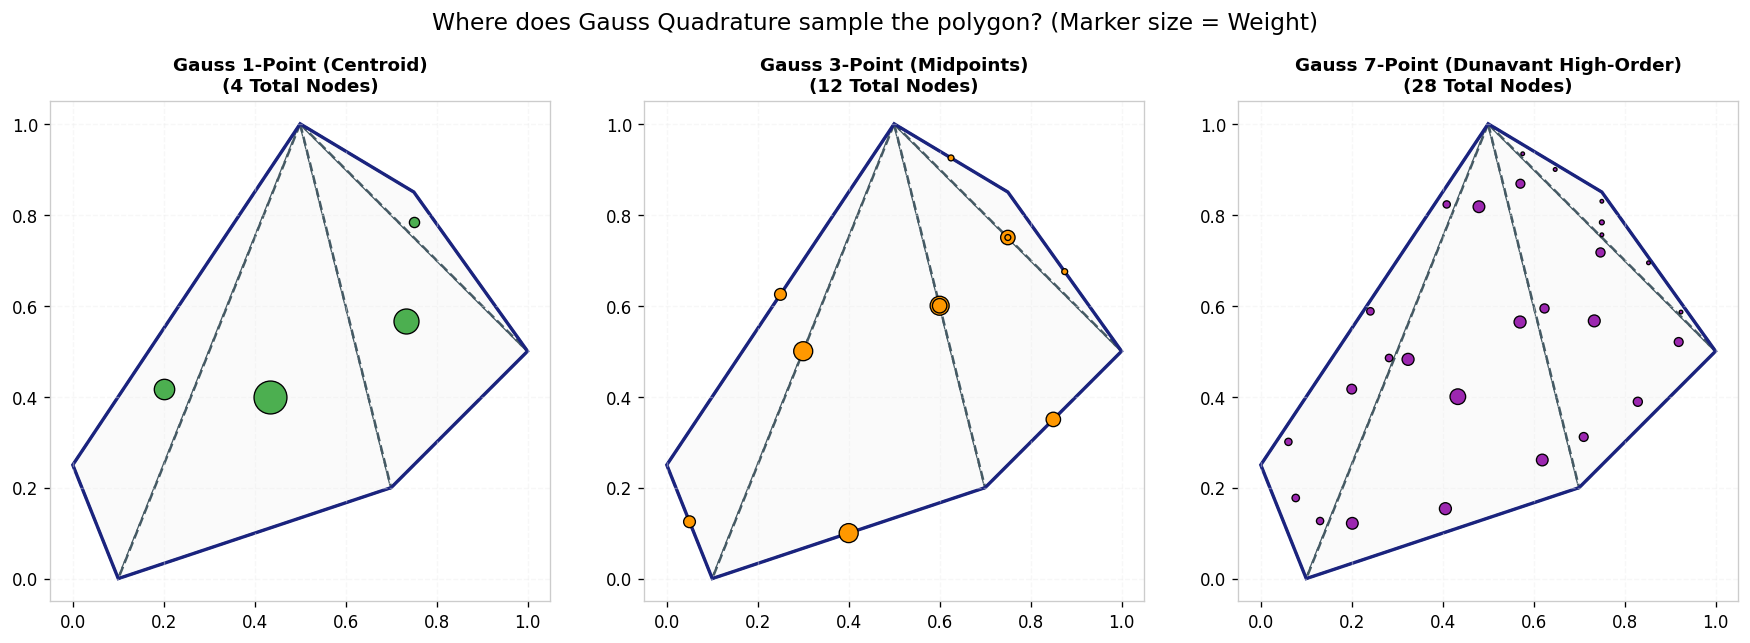

In [13]:
# ==============================================================================
# Method 1 Implementation: Triangulation + Gauss Quadrature
# ==============================================================================

# Define the 4 triangles fanning from vertex F
triangles = [
    (polygon_vertices[5], polygon_vertices[0], polygon_vertices[1]), # F, A, B
    (polygon_vertices[5], polygon_vertices[1], polygon_vertices[2]), # F, B, C
    (polygon_vertices[5], polygon_vertices[2], polygon_vertices[3]), # F, C, D
    (polygon_vertices[5], polygon_vertices[3], polygon_vertices[4])  # F, D, E
]

def triangle_area(p0, p1, p2):
    """Calculates signed area of triangle (p0, p1, p2)"""
    return 0.5 * abs((p1[0] - p0[0]) * (p2[1] - p0[1]) - (p2[0] - p0[0]) * (p1[1] - p0[1]))

def get_gauss_points_1pt(p0, p1, p2):
    """1-point centroid rule"""
    area = triangle_area(p0, p1, p2)
    centroid = (p0 + p1 + p2) / 3.0
    return np.array([centroid]), np.array([area])

def get_gauss_points_3pt(p0, p1, p2):
    """3-point midpoint rule (degree 2 precision)"""
    area = triangle_area(p0, p1, p2)
    pts = np.array([0.5*(p0+p1), 0.5*(p1+p2), 0.5*(p2+p0)])
    weights = np.array([area / 3.0, area / 3.0, area / 3.0])
    return pts, weights

def get_gauss_points_7pt(p0, p1, p2):
    """7-point Dunavant rule (degree 5 precision)"""
    area = triangle_area(p0, p1, p2)
    # Centroid
    w_c = 0.225 * area
    b_c = [1/3, 1/3, 1/3]
    # Ring 1
    r = (6.0 - np.sqrt(15.0)) / 21.0
    w_r = ((155.0 - np.sqrt(15.0)) / 1200.0) * area
    b_r = [[r, r, 1 - 2*r], [r, 1 - 2*r, r], [1 - 2*r, r, r]]
    # Ring 2
    s = (6.0 + np.sqrt(15.0)) / 21.0
    w_s = ((155.0 + np.sqrt(15.0)) / 1200.0) * area
    b_s = [[s, s, 1 - 2*s], [s, 1 - 2*s, s], [1 - 2*s, s, s]]
    
    bary = np.vstack([[b_c], b_r, b_s])
    weights = np.hstack([[w_c], [w_r]*3, [w_s]*3])
    # Convert barycentric coordinates to Cartesian coordinates
    pts = bary[:, 0:1]*p0 + bary[:, 1:2]*p1 + bary[:, 2:3]*p2
    return pts, weights

# Visual Comparison of Sample Point Placement
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
rules = [
    ("Gauss 1-Point (Centroid)", get_gauss_points_1pt, '#4CAF50'),
    ("Gauss 3-Point (Midpoints)", get_gauss_points_3pt, '#FF9800'),
    ("Gauss 7-Point (Dunavant High-Order)", get_gauss_points_7pt, '#9C27B0')
]

for ax, (title, rule_func, color) in zip(axes, rules):
    # Draw triangles
    for tri in triangles:
        t_patch = patches.Polygon(tri, closed=True, facecolor='#FAFAFA', edgecolor='#455A64', lw=1.5, ls='--')
        ax.add_patch(t_patch)
        pts, w = rule_func(*tri)
        # Dot size is proportional to weight!
        ax.scatter(pts[:, 0], pts[:, 1], s=w * 1500, color=color, zorder=5, edgecolor='black', lw=0.8)
    
    # Outer polygon border
    poly_patch = patches.Polygon(polygon_vertices, closed=True, fill=False, edgecolor='#1A237E', lw=2)
    ax.add_patch(poly_patch)
    
    ax.set_title(f"{title}\n({4 * len(pts)} Total Nodes)", fontsize=11, weight='bold')
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.4)

plt.suptitle("Where does Gauss Quadrature sample the polygon? (Marker size = Weight)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 🚶 Section 3b: Green's Theorem – "Walking Along the Fence" (Slides 20–46)

In Slides 20 through 46 of the lecture presentation, there is an entire chapter on **Green's Theorem**:
$$\iint_D \left(\frac{\partial Q}{\partial x} - \frac{\partial P}{\partial y}\right) dxdy = \oint_{\partial D} (P dx + Q dy)$$

### Why is this so magical for non-mathematicians?
> 💡 **The Fence Analogy:**  
> Normally, to measure the area or volume inside a backyard, you have to walk over every square meter inside the lawn.  
> **Green's theorem says you don't even need to step inside the yard!**  
> If you just walk along the perimeter fence ($\\partial D$) and evaluate 1D Gauss–Legendre quadrature along each straight fence segment, you get the exact 2D volume enclosed inside!

For a straight edge between $(x_1, y_1)$ and $(x_2, y_2)$, the edge is a 1D line:
$$x(t) = x_1 + t(x_2 - x_1), \quad y(t) = y_1 + t(y_2 - y_1), \quad t \in [0, 1]$$
We can simply use standard 1D Gauss quadrature points along each edge. This shows how 1D Gauss quadrature directly solves 2D polygon integration!


---
## 🧩 Section 4: Method 2 – The 8-Node Spline Finite Element (Li et al. 2009)

### 📊 De-mystifying the Course Spreadsheet
In the class spreadsheet, you will find columns for:
* Corners: $V_1, V_2, V_3, V_4$
* Center: $V_0(x_0, y_0)$
* Ratios: $a, b, c, d$
* Triangular sub-areas: $S_1, S_2, S_3, S_4$
* 8 Weights: $C_{V_1}, \dots, C_{V_4}$ and $C_{E_1}, \dots, C_{E_4}$

This comes from the 2009 research paper by **Chong-Jun Li, Paola Lamberti, and Catterina Dagnino** (*Journal of Computational and Applied Mathematics*, Vol. 233, pp. 279–292).

### The Geometric Construction (Slide 48–50)
For each 4-sided quadrilateral element $Q = \square V_1 V_2 V_3 V_4$:
1. **Find Diagonal Intersection $V_0$:**  
   Draw the two diagonals $V_1 V_3$ and $V_2 V_4$. Their intersection is the internal balance point $V_0(x_0, y_0)$.
2. **Compute 4 Sub-Triangle Areas ($S_1, S_2, S_3, S_4$):**  
   The diagonals divide the quad into 4 triangles meeting at $V_0$:
   * $S_1 = \text{Area}(\triangle V_0 V_1 V_2)$
   * $S_2 = \text{Area}(\triangle V_0 V_2 V_3)$
   * $S_3 = \text{Area}(\triangle V_0 V_3 V_4)$
   * $S_4 = \text{Area}(\triangle V_0 V_4 V_1)$
   * Total Area $S = S_1 + S_2 + S_3 + S_4$.
3. **Compute Diagonal Ratios:**  
   $$a = \frac{|V_4 V_0|}{|V_4 V_2|}, \quad b = \frac{|V_3 V_0|}{|V_3 V_1|}, \quad c = 1 - a, \quad d = 1 - b$$
4. **Place the 8 Nodes:**  
   * 4 Corner Vertices: $V_1, V_2, V_3, V_4$
   * 4 Edge Midpoints: $E_1 = \frac{V_1+V_2}{2}, E_2 = \frac{V_2+V_3}{2}, E_3 = \frac{V_3+V_4}{2}, E_4 = \frac{V_4+V_1}{2}$
5. **Assign the 8 Weights:**  
   * Corner weights (negative balancing factors): $C_{V_1} = -\frac{1}{6} b S, \dots$
   * Edge midpoint weights: $C_{E_1} = \frac{1}{3}[(1 + a + b + ab)S_1 + (b + ab)S_2 + ab S_3 + (a + ab)S_4], \dots$

Let's write this clean, modular algorithm in Python and draw an annotated geometric diagram!


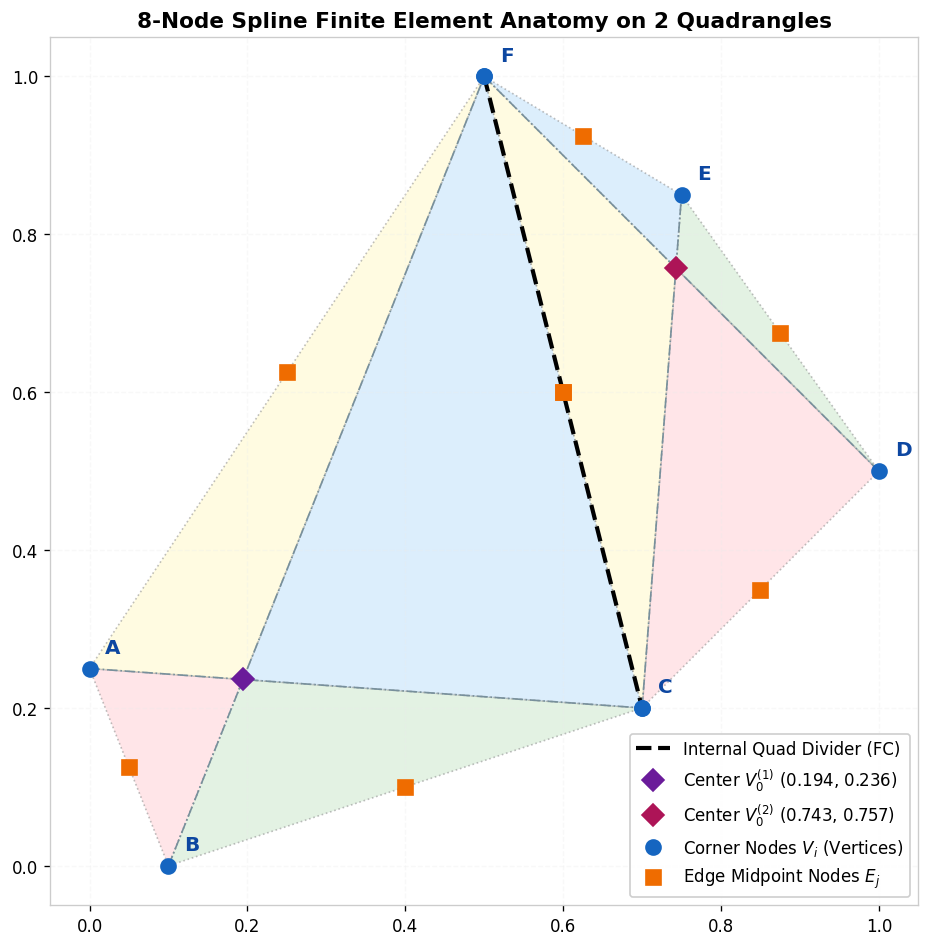

In [14]:
# ==============================================================================
# Method 2 Implementation: 8-Node Quadrilateral Spline (Li et al. 2009)
# ==============================================================================

def solve_8node_quad(V, quad_name="Quad"):
    """
    Computes geometry, nodes, and weights for an 8-node quadrilateral spline element.
    V: (4, 2) numpy array of quadrilateral vertices in counter-clockwise order.
    """
    V1, V2, V3, V4 = V[0], V[1], V[2], V[3]
    
    # 1. Intersection of diagonals V1-V3 and V4-V2
    # V1 + t*(V3 - V1) = V4 + s*(V2 - V4)
    A_mat = np.column_stack([V3 - V1, -(V2 - V4)])
    t, s = np.linalg.solve(A_mat, V4 - V1)
    V0 = V1 + t * (V3 - V1)
    
    # 2. Diagonal split ratios
    a = s
    c = 1.0 - a
    b = 1.0 - t
    d = 1.0 - b
    
    # 3. Four sub-triangle areas around V0
    def sub_area(p0, p1, p2):
        return 0.5 * ((p1[0] - p0[0]) * (p2[1] - p0[1]) - (p2[0] - p0[0]) * (p1[1] - p0[1]))
    
    S1 = sub_area(V0, V1, V2)
    S2 = sub_area(V0, V2, V3)
    S3 = sub_area(V0, V3, V4)
    S4 = sub_area(V0, V4, V1)
    S = S1 + S2 + S3 + S4
    
    # 4. Midpoints of the 4 edges
    E1 = 0.5 * (V1 + V2)
    E2 = 0.5 * (V2 + V3)
    E3 = 0.5 * (V3 + V4)
    E4 = 0.5 * (V4 + V1)
    
    # 5. The 8 weights (from Slide 50 & spreadsheet formulas)
    CV1 = -(1.0 / 6.0) * b * S
    CV2 = -(1.0 / 6.0) * a * S
    CV3 = -(1.0 / 6.0) * d * S
    CV4 = -(1.0 / 6.0) * c * S
    
    CE1 = (1.0 / 3.0) * ((1 + a + b + a*b)*S1 + (b + a*b)*S2 + (a*b)*S3 + (a + a*b)*S4)
    CE2 = (1.0 / 3.0) * ((d + a*d)*S1 + (1 + a + d + a*d)*S2 + (a + a*d)*S3 + (a*d)*S4)
    CE3 = (1.0 / 3.0) * ((c*d)*S1 + (c + c*d)*S2 + (1 + c + d + c*d)*S3 + (d + c*d)*S4)
    CE4 = (1.0 / 3.0) * ((c + b*c)*S1 + (b*c)*S2 + (b + b*c)*S3 + (1 + b + c + b*c)*S4)
    
    nodes = {
        'vertices': np.array([V1, V2, V3, V4]),
        'midpoints': np.array([E1, E2, E3, E4]),
        'V0': V0
    }
    
    weights = {
        'C_V': np.array([CV1, CV2, CV3, CV4]),
        'C_E': np.array([CE1, CE2, CE3, CE4])
    }
    
    geom = {
        'a': a, 'b': b, 'c': c, 'd': d,
        'S1': S1, 'S2': S2, 'S3': S3, 'S4': S4, 'S_total': S
    }
    
    return nodes, weights, geom

# Let's solve Quad 1: [A, B, C, F] and Quad 2: [C, D, E, F]
A, B, C, D, E, F = polygon_vertices
quad1_nodes, quad1_weights, quad1_geom = solve_8node_quad(np.array([A, B, C, F]), "Quad 1")
quad2_nodes, quad2_weights, quad2_geom = solve_8node_quad(np.array([C, D, E, F]), "Quad 2")

# Visual Diagram of the 8-Node Spline Partition
fig, ax = plt.subplots(figsize=(9, 8))

# Draw 4 colored subtriangles for Quad 1
colors_sub = ['#FFCDD2', '#C8E6C9', '#BBDEFB', '#FFF9C4']
v0_1 = quad1_nodes['V0']
v1_pts = quad1_nodes['vertices']
for i in range(4):
    tri_pts = [v0_1, v1_pts[i], v1_pts[(i+1)%4]]
    ax.add_patch(patches.Polygon(tri_pts, closed=True, facecolor=colors_sub[i], alpha=0.5, edgecolor='gray', ls=':'))

# Draw 4 colored subtriangles for Quad 2
v0_2 = quad2_nodes['V0']
v2_pts = quad2_nodes['vertices']
for i in range(4):
    tri_pts = [v0_2, v2_pts[i], v2_pts[(i+1)%4]]
    ax.add_patch(patches.Polygon(tri_pts, closed=True, facecolor=colors_sub[i], alpha=0.5, edgecolor='gray', ls=':'))

# Draw the shared separating edge FC
ax.plot([F[0], C[0]], [F[1], C[1]], 'k--', lw=2.5, label='Internal Quad Divider (FC)')

# Draw the diagonals
ax.plot([A[0], C[0]], [A[1], C[1]], color='#78909C', lw=1, ls='-.')
ax.plot([B[0], F[0]], [B[1], F[1]], color='#78909C', lw=1, ls='-.')
ax.plot([C[0], E[0]], [C[1], E[1]], color='#78909C', lw=1, ls='-.')
ax.plot([D[0], F[0]], [D[1], F[1]], color='#78909C', lw=1, ls='-.')

# Plot Diagonals Intersection Points V0
ax.plot(v0_1[0], v0_1[1], 'D', color='#6A1B9A', markersize=9, label=f'Center $V_0^{{(1)}}$ ({v0_1[0]:.3f}, {v0_1[1]:.3f})')
ax.plot(v0_2[0], v0_2[1], 'D', color='#AD1457', markersize=9, label=f'Center $V_0^{{(2)}}$ ({v0_2[0]:.3f}, {v0_2[1]:.3f})')

# Plot the 4 Corner Nodes (Blue)
all_corners = np.vstack([quad1_nodes['vertices'], quad2_nodes['vertices']])
ax.plot(all_corners[:, 0], all_corners[:, 1], 'o', color='#1565C0', markersize=9, label='Corner Nodes $V_i$ (Vertices)')

# Plot the 4 Edge Midpoint Nodes (Orange)
all_mids = np.vstack([quad1_nodes['midpoints'], quad2_nodes['midpoints']])
ax.plot(all_mids[:, 0], all_mids[:, 1], 's', color='#EF6C00', markersize=9, label='Edge Midpoint Nodes $E_j$')

# Annotate vertices
for (x, y), name in zip(polygon_vertices, vertex_names):
    ax.text(x + 0.02, y + 0.02, name, fontsize=12, weight='bold', color='#0D47A1')

ax.set_title("8-Node Spline Finite Element Anatomy on 2 Quadrangles", fontsize=13, weight='bold')
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.set_aspect('equal')
ax.legend(loc='lower right', frameon=True, facecolor='white', framealpha=0.95)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## 🏆 Section 5: Head-to-Head Comparison on Lecture Benchmarks

Now comes the exciting part! Let's compare both methods against the **exact analytical answers** for our two lecture test functions:
* **$f_1$ (Steep Mountain Peak)**: True Integral $I_{\text{true}}^{(1)} \approx 0.031414529$
* **$f_2$ (Conical Funnel)**: True Integral $I_{\text{true}}^{(2)} \approx 0.156825126$

We will evaluate:
1. **Gauss 1-Point Rule** (4 nodes total)
2. **Gauss 3-Point Rule** (12 nodes total)
3. **8-Node Spline FE** (13 unique nodes total across the 2 quads)
4. **Gauss 7-Point Dunavant Rule** (28 nodes total)

---

### 📏 How the Error is Computed

To quantitatively evaluate how well each numerical method approximates the true volume beneath each surface, we calculate two standard error metrics against the reference benchmark values ($I_{\text{true}}$):

#### 1. Absolute Error ($E_{\text{abs}}$)
The absolute error measures the raw magnitude of the difference between the numerical approximation ($I_{\text{approx}}$) and the ground-truth benchmark ($I_{\text{true}}$):
$$E_{\text{abs}} = \left| I_{\text{approx}} - I_{\text{true}} \right|$$
where the numerical cubature approximation is obtained by summing the weighted function evaluations at all sampling nodes $(x_k, y_k)$:
$$I_{\text{approx}} = \sum_{k=1}^{N} w_k \, f(x_k, y_k)$$

#### 2. Relative Error Percentage ($E_{\text{rel}}$)
The relative error normalizes the absolute error by the true value, expressing the deviation as a percentage:
$$E_{\text{rel}} (\%) = \frac{\left| I_{\text{approx}} - I_{\text{true}} \right|}{I_{\text{true}}} \times 100\% = \frac{E_{\text{abs}}}{I_{\text{true}}} \times 100\%$$

> 💡 **Why do we report Relative Error (%) instead of Absolute Error?**  
> * **Scale Independence:** The true integral of $f_2$ ($\approx 0.1568$) is roughly **5 times larger** than that of $f_1$ ($\approx 0.0314$). An absolute discrepancy of $0.005$ would represent a small $\sim 3.2\%$ error on $f_2$, but a large $\sim 16\%$ error on $f_1$.  
> * **Fair Cross-Benchmark Comparison:** Normalizing by $I_{\text{true}}$ brings both benchmarks onto a common percentage scale, enabling an apples-to-apples comparison across distinct mathematical surfaces and domain geometries.  
> * **Interpreting the Results:** In both the summary table and the bar chart below, **lower percentage error indicates higher accuracy** and closer convergence to the exact value.

Let's compute the results and inspect the comparison table!


,Method,Nodes,f1 Approx,f1 Rel Error (%),f2 Approx,f2 Rel Error (%)
0,Gauss 1-Point (Centroid),4,0.061750,96.56%,0.108231,30.99%
1,Gauss 3-Point (Midpoints),12,0.020707,34.08%,0.154707,1.35%
3,8-Node Spline FE (Li et al.),13,0.024183,23.02%,0.157222,0.25%
2,Gauss 7-Point (Dunavant),28,0.031258,0.50%,0.156342,0.31%


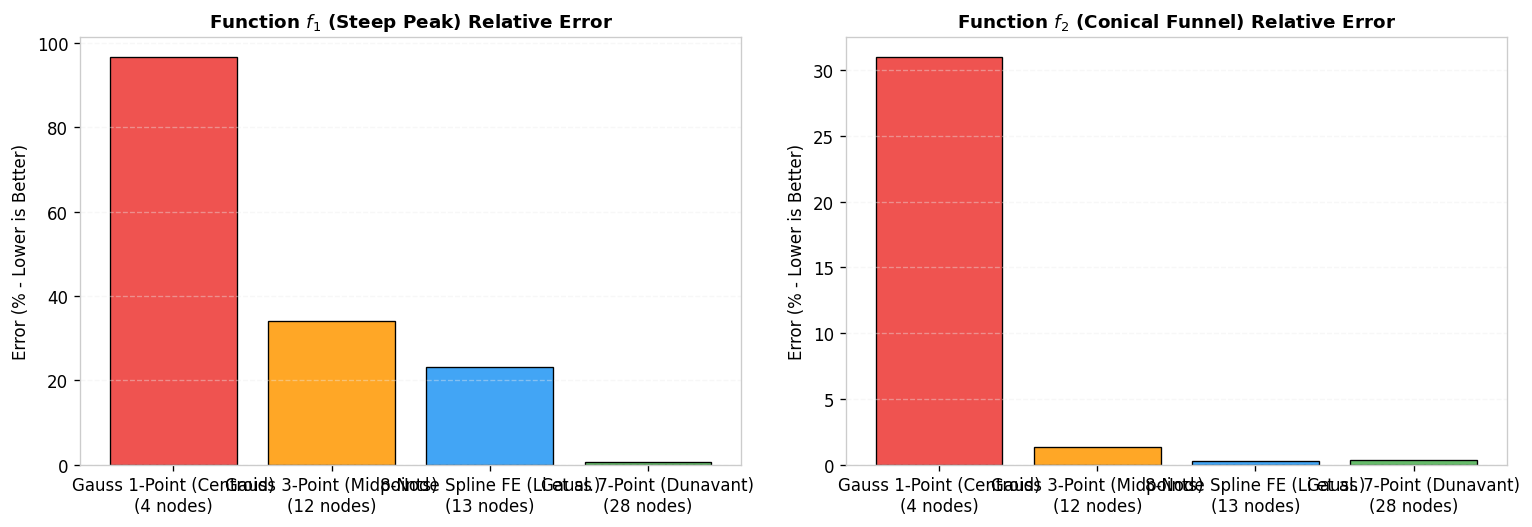

In [15]:
# Exact reference values from high-precision adaptive quadrature
TRUE_I1 = 0.031414529
TRUE_I2 = 0.156825126

# 1. Compute Gauss Quadrature Results
gauss_methods = [
    ("Gauss 1-Point (Centroid)", get_gauss_points_1pt),
    ("Gauss 3-Point (Midpoints)", get_gauss_points_3pt),
    ("Gauss 7-Point (Dunavant)", get_gauss_points_7pt)
]

results = []

for name, rule in gauss_methods:
    pts_list, w_list = [], []
    for tri in triangles:
        p, w = rule(*tri)
        pts_list.append(p)
        w_list.append(w)
    pts_all = np.vstack(pts_list)
    w_all = np.hstack(w_list)
    
    # Numerical cubature approximation: I_approx = sum(w_i * f(x_i, y_i))
    val1 = np.sum(w_all * f1(pts_all[:, 0], pts_all[:, 1]))
    val2 = np.sum(w_all * f2(pts_all[:, 0], pts_all[:, 1]))
    
    # Absolute error: E_abs = |I_approx - I_true|
    err1 = abs(val1 - TRUE_I1)
    err2 = abs(val2 - TRUE_I2)
    
    # Relative error (%): E_rel = (E_abs / I_true) * 100%
    rel1 = (err1 / TRUE_I1) * 100.0
    rel2 = (err2 / TRUE_I2) * 100.0
    
    results.append({
        'Method': name,
        'Nodes': len(w_all),
        'f1 Approx': val1,
        'f1 Rel Error (%)': rel1,
        'f2 Approx': val2,
        'f2 Rel Error (%)': rel2
    })

# 2. Compute 8-Node Spline FE Result
# Quad 1 integration: sum(C_V * f(V)) + sum(C_E * f(E))
q1_val1 = np.sum(quad1_weights['C_V'] * f1(quad1_nodes['vertices'][:, 0], quad1_nodes['vertices'][:, 1])) + \
          np.sum(quad1_weights['C_E'] * f1(quad1_nodes['midpoints'][:, 0], quad1_nodes['midpoints'][:, 1]))
q1_val2 = np.sum(quad1_weights['C_V'] * f2(quad1_nodes['vertices'][:, 0], quad1_nodes['vertices'][:, 1])) + \
          np.sum(quad1_weights['C_E'] * f2(quad1_nodes['midpoints'][:, 0], quad1_nodes['midpoints'][:, 1]))

# Quad 2 integration: sum(C_V * f(V)) + sum(C_E * f(E))
q2_val1 = np.sum(quad2_weights['C_V'] * f1(quad2_nodes['vertices'][:, 0], quad2_nodes['vertices'][:, 1])) + \
          np.sum(quad2_weights['C_E'] * f1(quad2_nodes['midpoints'][:, 0], quad2_nodes['midpoints'][:, 1]))
q2_val2 = np.sum(quad2_weights['C_V'] * f2(quad2_nodes['vertices'][:, 0], quad2_nodes['vertices'][:, 1])) + \
          np.sum(quad2_weights['C_E'] * f2(quad2_nodes['midpoints'][:, 0], quad2_nodes['midpoints'][:, 1]))

spline_val1 = q1_val1 + q2_val1
spline_val2 = q1_val2 + q2_val2

# Note: The shared edge FC shares 2 vertices and 1 midpoint, so 16 - 3 = 13 unique node evaluations!
# Relative error (%): (|I_approx - I_true| / I_true) * 100%
results.append({
    'Method': '8-Node Spline FE (Li et al.)',
    'Nodes': 13,
    'f1 Approx': spline_val1,
    'f1 Rel Error (%)': abs(spline_val1 - TRUE_I1) / TRUE_I1 * 100.0,
    'f2 Approx': spline_val2,
    'f2 Rel Error (%)': abs(spline_val2 - TRUE_I2) / TRUE_I2 * 100.0
})

# Display clean DataFrame table
df = pd.DataFrame(results).sort_values('Nodes')
display(df.style.format({
    'f1 Approx': '{:.6f}',
    'f1 Rel Error (%)': '{:.2f}%',
    'f2 Approx': '{:.6f}',
    'f2 Rel Error (%)': '{:.2f}%'
}).background_gradient(subset=['f1 Rel Error (%)', 'f2 Rel Error (%)'], cmap='YlOrRd_r'))

# Visual Bar Chart Comparison
fig, (ax_bar1, ax_bar2) = plt.subplots(1, 2, figsize=(13, 4.5))

methods = df['Method'].tolist()
nodes = df['Nodes'].tolist()
labels = [f"{m}\n({n} nodes)" for m, n in zip(methods, nodes)]
colors = ['#EF5350', '#FFA726', '#42A5F5', '#66BB6A']

ax_bar1.bar(labels, df['f1 Rel Error (%)'], color=colors, edgecolor='black', lw=0.8)
ax_bar1.set_title("Function $f_1$ (Steep Peak) Relative Error", fontsize=11, weight='bold')
ax_bar1.set_ylabel("Error (% - Lower is Better)")
ax_bar1.grid(axis='y', alpha=0.4)

ax_bar2.bar(labels, df['f2 Rel Error (%)'], color=colors, edgecolor='black', lw=0.8)
ax_bar2.set_title("Function $f_2$ (Conical Funnel) Relative Error", fontsize=11, weight='bold')
ax_bar2.set_ylabel("Error (% - Lower is Better)")
ax_bar2.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()


---
## 🎓 Section 7: Key Takeaways – Which Method Should You Use?

| Feature | Gauss–Legendre on Triangles | 8-Node Spline Finite Elements (Li et al.) |
| :--- | :--- | :--- |
| **Domain Element** | **Triangles** (easy to mesh any shape) | **Quadrilaterals** (structured 4-sided blocks) |
| **Node Placement** | Strictly **inside** each triangle | On **corners** and **edge midpoints** |
| **Scalability** | Easy to increase precision (1, 3, 7, 19, 37 points) | Fixed **8 nodes per quadrilateral** |
| **Best For** | Arbitrary shapes, boundary line integrals (Green's theorem) | Finite element meshes in mechanical/structural simulation |
| **Boundary Sharing** | Shared edges do not share interior Gauss points | Neighboring quads **share corner and midpoint nodes**, saving function evaluations! |

---

### 🧠 Quick Self-Check Questions:
1. **Why does Gauss–Legendre use 7 points on each triangle instead of 70?**  
   *Because Legendre roots are placed at mathematically optimal locations that cancel out polynomial errors of degree up to $2n - 1$.*
2. **Why are some vertex weights in the 8-node spline negative?**  
   *Because the edge midpoint nodes receive positive weights ($C_{E_j} > 0$). Negative corner weights compensate for the overlap, creating a smooth $C^1$ spline interpolant.*
3. **What is the purpose of Green's theorem in polygon integration?**  
   *It transforms a 2D surface integral over the interior into 1D line integrals along the boundary edges, eliminating the need to mesh the interior!*

---
*Created for the Inter-University Collaborative Algorithms Project.*
